# Определение метрик качества модели

In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
os.chdir(project_root)
sys.path.insert(0, str(project_root))
(project_root / "logs").mkdir(exist_ok=True)

In [2]:
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [3]:
from scripts.run_pipeline import run_pipeline

### Запуск пайплайна

In [4]:
!python -m scripts.run_pipeline --input_dir data/raw \
--output_dir output \
--prefix test \
--yolo-conf 0.1 \
--ocr-conf 0.2 \
--conf 0.2 \
--confidence-level-threshold 0.8

🚀 SEFER VISION PIPELINE
📂 Входная папка     : data/raw
📁 Выходная папка    : output
🏷️  Префикс          : test
🎯 YOLO conf         : 0.1
✅ CONF_THRESHOLD    : 0.2
🔤 OCR accept conf   : 0.2
📊 Confidence level  : 0.8
-----------------------------------------------------------------------------------------------

📊 ИТОГОВЫЙ ОТЧЁТ
Файлов обработано     : 1200
Успешно               : 769 (64.1%)
С сомнением           : 179
Не распознано         : 252
Отчёт: output\sefer_report.csv



Обработка фотографий: 100%|██████████| 1200/1200 [53:07<00:00,  2.66s/фото]


In [5]:
df = pd.read_csv('output\sefer_report.csv')
df.head()

,Имя_файла,Путь_к_оригиналу,Уверенность_детекции,crop_path,Распознанный_текст,Уверенность_OCR,Чистый_номер,Новое_имя_файла,Путь_к_финальному_файлу,Статус,Сообщение,Общий_уровень_уверенности
0,MDZ086.JPG,data\raw\MDZ086.JPG,0.976319,NaN,86.0,0.982021,86.0,test0086.jpg,output\success\test0086.jpg,success,| Детекция: 0.976 | OCR: 0.982,0.96
1,MDZ086_1.JPG,data\raw\MDZ086_1.JPG,0.969371,NaN,86.0,0.976128,86.0,test0086_1.jpg,output\success\test0086_1.jpg,success,| Детекция: 0.969 | OCR: 0.976,0.95
2,MDZ086_2.JPG,data\raw\MDZ086_2.JPG,0.909828,NaN,NaN,0.774016,NaN,NaN,output\very_low\MDZ086_2.JPG,very_low_confidence,"Детекция OK (0.910), но OCR не прочитал номер ...",0.70
3,MDZ087 _1.JPG,data\raw\MDZ087 _1.JPG,0.968696,NaN,87.0,0.974910,87.0,test0087.jpg,output\success\test0087.jpg,success,| Детекция: 0.969 | OCR: 0.975,0.94
4,MDZ087 _10.JPG,data\raw\MDZ087 _10.JPG,0.956259,NaN,87.0,0.978307,87.0,test0087_1.jpg,output\success\test0087_1.jpg,success,| Детекция: 0.956 | OCR: 0.978,0.94


In [6]:
df_work = df.copy()

In [7]:
df_work['real_number'] = df_work['Имя_файла'].str.extract(r'^[A-Za-z]+\s*(\d+)')[0].str.zfill(4)
df_work['assigned_number'] = df_work['Новое_имя_файла'].str.extract(r'^[A-Za-z]+\s*(\d+)')[0]

In [8]:
df_metr = df_work[['Имя_файла', 'Общий_уровень_уверенности', 'real_number', 'assigned_number']]
df_metr['assigned_number'] = df_metr['assigned_number'].fillna('не_распознано')
df_metr.head()

,Имя_файла,Общий_уровень_уверенности,real_number,assigned_number
0,MDZ086.JPG,0.96,0086,0086
1,MDZ086_1.JPG,0.95,0086,0086
2,MDZ086_2.JPG,0.70,0086,не_распознано
3,MDZ087 _1.JPG,0.94,0087,0087
4,MDZ087 _10.JPG,0.94,0087,0087


## Accuracy

In [9]:
y_true = df_metr['real_number']
y_pred = df_metr['assigned_number']
accuracy = accuracy_score(y_true, y_pred)

In [10]:
print(f"Accuracy = {accuracy:.02f}")

Accuracy = 0.67


## ROC_AUC

Разметка правильности:
      Имя_файла  correct  Общий_уровень_уверенности
0    MDZ086.JPG        1                       0.96
1  MDZ086_1.JPG        1                       0.95
2  MDZ086_2.JPG        0                       0.70

ROC-AUC: 0.9281


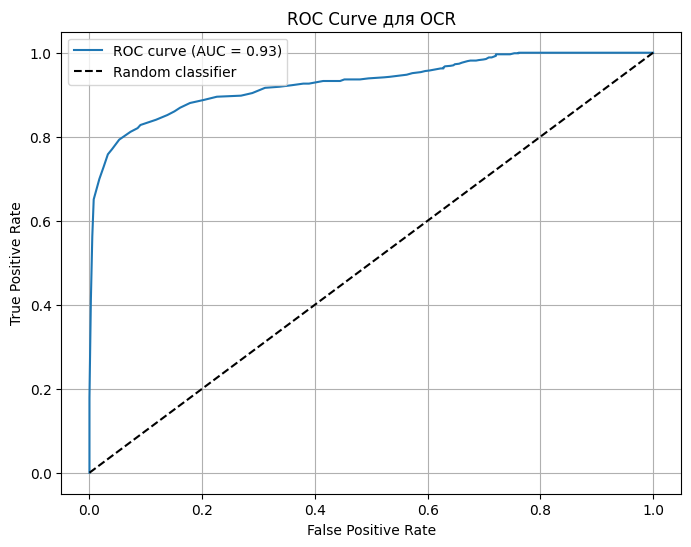

In [11]:
# 1. Создаем бинарные метки (1 - правильно, 0 - ошибка/не распознано)
df_metr['correct'] = (df_metr['real_number'] == df_metr['assigned_number']).astype(int)

print("Разметка правильности:")
print(df_metr[['Имя_файла', 'correct', 'Общий_уровень_уверенности']].head(3))

# 2. Проверяем, есть ли оба класса (иначе roc_auc не посчитать)
if df_metr['correct'].nunique() > 1:
    auc = roc_auc_score(df_metr['correct'], df_metr['Общий_уровень_уверенности'])
    print(f"\nROC-AUC: {auc:.4f}")
else:
    print("\nНевозможно посчитать ROC-AUC: только один класс в выборке")

# 3. Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(df_metr['correct'], df_metr['Общий_уровень_уверенности'])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve для OCR')
plt.legend()
plt.grid()
plt.show()